In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
root = os.getcwd()
root

'/home/peiretti/fair-clustering/datasets/amazon'

In [29]:
df = pd.read_csv(root + "/AmazonData.csv")
df

,RevId,firstname,helpfulVotes,totalVotes,RevText,rating,RevTitle,Unix.RevTime,month,year,Category,gender,genderprobability,female,male,helpfulnessT,reviewwords,titlewords
0,AIWIEN0F9YDRZ,amy,0,1,MY son works on the railroad and these gloves ...,5,good looking and functional,1389398400,1,2014,Home and Tools,female,0.99,1,0,0.000000,30,4
1,A3PNHWIMESAO1O,ann,0,1,I just decided to go with the Moen DN6718ORB D...,3,this product was fine,1389139200,1,2014,Home and Tools,female,0.99,1,0,0.000000,23,4
2,AU2FLCLW8W04P,liz,0,1,Fit well into our sparkling grape juice bottle...,5,Fit Well,1389052800,1,2014,Home and Tools,female,1.00,1,0,0.000000,42,2
3,A1C6HTWGSMORUB,beth,0,6,I thought that my teenagers would like these k...,1,"The Product was good, but customer service not...",1389398400,1,2014,Home and Tools,female,1.00,1,0,0.000000,193,10
4,AZ7OW7KDTEHCG,judy,0,1,"with this thing , It might be good for getting...",1,I ruined my sinks,1389744000,1,2014,Home and Tools,female,1.00,1,0,0.000000,23,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3257,A14KE7T0SLIY7D,rachel,6,7,I slathered this on (maybe more than recommend...,5,whoa,1391385600,2,2014,Beauty,female,1.00,1,0,0.857143,107,1
3258,A2DKT52VOXP3GT,nicole,16,18,Using this mask with just water or apple cider...,4,"Good as-is, GREAT with additions.",1390780800,1,2014,Beauty,female,1.00,1,0,0.888889,560,5
3259,AOPNY16ME3MLW,danielle,9,10,This made my hair grow and stop breaking. i ha...,5,thickens hair and stops breakage,1389225600,1,2014,Beauty,female,1.00,1,0,0.900000,40,5
3260,A2LZN4FEW82YPM,elizabeth,10,11,Wrinkles even seemed worse with the Revitol-I ...,1,Did not help and caused more wrinkles and made...,1393113600,2,2014,Beauty,female,1.00,1,0,0.909091,37,12


In [4]:
len(df[(df["gender"]=="female") & (df["Category"]=="Beauty")])

1280

In [5]:
len(df[(df["gender"]=="female") & (df["Category"]=="Home and Tools")])

359

In [6]:
len(df[(df["gender"]=="male") & (df["Category"]=="Home and Tools")])

1144

In [7]:
len(df[(df["gender"]=="male") & (df["Category"]=="Beauty")])

479

In [8]:
df = pd.read_csv(root + "/tokens.csv")
df

,firstname,gender,tokens
0,aaron,male,"['local', 'lumber', 'yard', 'hardwar', 'dont',..."
1,abigail,female,"['realli', 'dont', 'rememb', 'need', 'product'..."
2,adam,male,"['littl', 'heater', 'plenti', 'strong', 'enoug..."
3,adriana,female,"['expect', 'bought', 'sefora', 'befor', 'dont'..."
4,adriano,male,"['realli', 'love', 'one', 'realli', 'pretti', ..."
...,...,...,...
700,yesenia,female,"['decid', 'buy', 'becaus', 'ouidad', 'made', '..."
701,yolanda,female,"['use', 'product', 'control', 'frizz', 'live',..."
702,yvonne,female,"['love', 'cologn', 'expens', 'everywher', 'els..."
703,zach,male,"['good', 'set', 'small', 'fault', 'know', 'siz..."


In [9]:
V = np.load(root + "/matrix.npy")
Sx = np.load(root + "/gender.npy")

In [10]:
V.shape

(705, 10152)

In [11]:
Sx.shape

(705,)

In [12]:
Sx_counter = Counter(Sx)
Sx_counter


Counter({0: 275, 1: 430})

In [13]:
np.unique(V, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 32, 33, 41, 45,
        46, 63], dtype=int32),
 array([7081562,   56455,   11369,    3920,    1622,     855,     421,
            291,     175,     120,      88,      66,      50,      28,
             33,      22,      12,      12,       8,       9,       7,
              7,       3,       4,       1,       3,       3,       4,
              1,       3,       1,       1,       1,       1,       1,
              1]))

In [14]:
group1 = np.where(Sx == 0)[0]
group2 = np.where(Sx == 1)[0]

In [15]:
V1 = V[group1, :]
V2 = V[group2, :]

In [16]:
V1.shape

(275, 10152)

In [17]:
V2.shape

(430, 10152)

In [18]:
words1 = np.sum(V1, axis=0)
words2 = np.sum(V2, axis=0)

In [19]:
# 0 male
# 1 female
# 2 both
preferred_words_by_gender = np.load(root + "/preferred_words_by_gender.npy")
preferred_words_by_gender

array([1, 0, 0, ..., 1, 1, 0], dtype=int32)

In [20]:
preferred_words_by_gender.shape

(10152,)

In [21]:
# 0 beauty
# 1 home
# 2 both
preferred_words_by_cat = np.load(root + "/preferred_words_by_category.npy")
preferred_words_by_cat

array([0, 1, 1, ..., 0, 0, 1], dtype=int32)

In [22]:
np.unique(preferred_words_by_cat, return_counts=True)

(array([0, 1, 2], dtype=int32), array([3701, 3823, 2628]))

In [23]:
words_str = np.load(root + "/words.npy")
words_str

array(['025oz', '04012014i', '08x20', ..., 'zpalett', 'zulera', 'zwave'],
      dtype='<U60')

In [24]:
import pandas as pd
df = pd.DataFrame(data={"words":words_str, "gender":preferred_words_by_gender, "category":preferred_words_by_cat})
df

,words,gender,category
0,025oz,1,0
1,04012014i,0,1
2,08x20,0,1
3,1000s,0,1
4,100lbs,1,1
...,...,...,...
10147,zone,0,0
10148,zone34,1,0
10149,zpalett,1,0
10150,zulera,1,0


In [25]:
male_beauty = df[(df["gender"] == 0) & (df["category"] == 0)]
female_beauty = df[(df["gender"] == 1) & (df["category"] == 0)]

male_home = df[(df["gender"] == 0) & (df["category"] == 1)]
female_home = df[(df["gender"] == 1) & (df["category"] == 1)]

male_both = df[(df["gender"] == 0) & (df["category"] == 2)]
female_both = df[(df["gender"] == 1) & (df["category"] == 2)]


In [26]:
print(f"male beauty: {len(male_beauty)}")
print(f"female beauty: {len(female_beauty)}")
print(f"male home: {len(male_home)}")
print(f"female home: {len(female_home)}")
print(f"male both: {len(male_both)}")
print(f"female both: {len(female_both)}")


male beauty: 1032
female beauty: 2233
male home: 2830
female home: 629
male both: 175
female both: 78


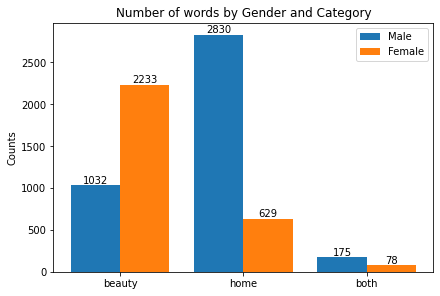

In [27]:
categories = ["beauty", "home", "both"]
counts = {
    "Male": [len(male_beauty), len(male_home), len(male_both)],
    "Female": [len(female_beauty), len(female_home), len(female_both)]
}

x = np.arange(len(categories))  # the label locations
width = 0.40  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in counts.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Counts')
ax.set_title('Number of words by Gender and Category')
ax.set_xticks(x + width/2, categories)
ax.legend(loc='upper right')


plt.show()

In [33]:
path_plot = "/home/peiretti/fair-clustering/plots/amazon"

/tmp/ipykernel_469351/879206746.py:33: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


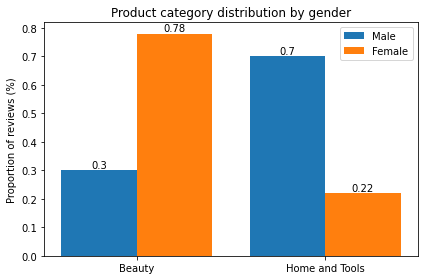

In [34]:
female_beauty = len(df[(df["gender"]=="female") & (df["Category"]=="Beauty")])
male_beauty = len(df[(df["gender"]=="male") & (df["Category"]=="Beauty")])

female_home = len(df[(df["gender"]=="female") & (df["Category"]=="Home and Tools")])
male_home = len(df[(df["gender"]=="male") & (df["Category"]=="Home and Tools")])

male_sum = male_beauty + male_home
female_sum = female_beauty + female_home

categories = ["Beauty", "Home and Tools"]
counts = {
    "Male": [np.round(male_beauty/male_sum,2), np.round(male_home/male_sum,2)],
    "Female": [np.round(female_beauty/female_sum,2), np.round(female_home/female_sum,2)]
}

x = np.arange(len(categories))  # the label locations
width = 0.40  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in counts.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Proportion of reviews (%)')
ax.set_title('Product category distribution by gender')
ax.set_xticks(x + width/2, categories)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(path_plot + "/category_by_gender.png", dpi=300, bbox_inches="tight")
#plt.show()

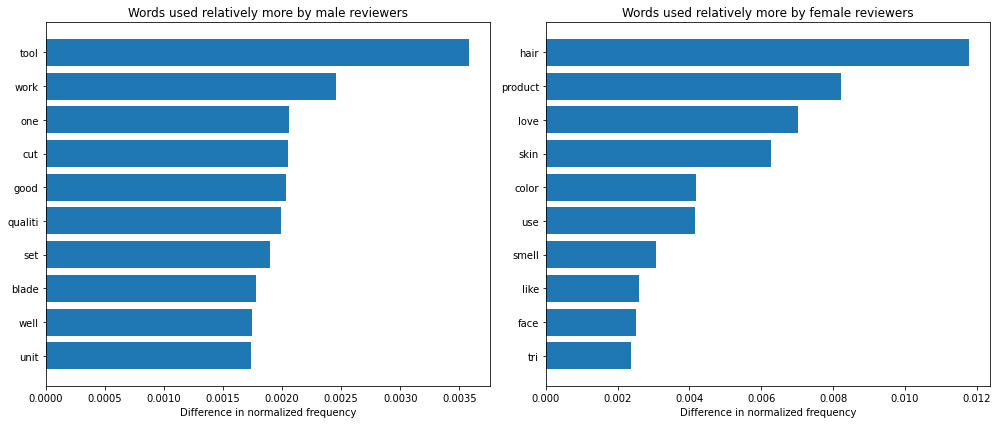

In [50]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os 

root = os.getcwd()

# -----------------------------
# Caricamento dati
# -----------------------------
with open(root + "/dict.json", "r") as f:
    user_word_freq = json.load(f)

tokens_df = pd.read_csv(root + "/tokens.csv")

# normalizzazione nomi/autori
tokens_df["firstname"] = tokens_df["firstname"].astype(str).str.lower().str.strip()
tokens_df["gender"] = tokens_df["gender"].astype(str).str.lower().str.strip()

# mapping autore -> gender
user_gender = dict(zip(tokens_df["firstname"], tokens_df["gender"]))

# -----------------------------
# Aggregazione frequenze parole per genere
# -----------------------------
male_counter = Counter()
female_counter = Counter()

for user, word_freqs in user_word_freq.items():
    g = user_gender.get(str(user).lower().strip(), None)
    if g == "male":
        male_counter.update(word_freqs)
    elif g == "female":
        female_counter.update(word_freqs)

# totale parole per ciascun genere
male_total = sum(male_counter.values())
female_total = sum(female_counter.values())


# vocabolario comune
all_words = set(male_counter.keys()) | set(female_counter.keys())

# frequenze normalizzate: P(word | gender)
male_prob = {}
female_prob = {}

for w in all_words:
    male_prob[w] = male_counter.get(w, 0) / male_total if male_total > 0 else 0.0
    female_prob[w] = female_counter.get(w, 0) / female_total if female_total > 0 else 0.0

# -----------------------------
# Bias score
# positivo -> parola relativamente più maschile
# negativo -> parola relativamente più femminile
# -----------------------------
filtered_bias = {w: male_prob[w] - female_prob[w] for w in all_words}

# top parole
top_k = 10

male_top = sorted(filtered_bias.items(), key=lambda x: x[1], reverse=True)[:top_k]
female_top = sorted(filtered_bias.items(), key=lambda x: x[1])[:top_k]

male_words = [x[0] for x in male_top]
male_scores = [x[1] for x in male_top]

female_words = [x[0] for x in female_top]
female_scores = [abs(x[1]) for x in female_top]  # per lunghezza barre positiva

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# parole relativamente più usate dai maschi
axes[0].barh(range(len(male_words)), male_scores[::-1])
axes[0].set_yticks(range(len(male_words)))
axes[0].set_yticklabels(male_words[::-1])
axes[0].set_xlabel("Difference in normalized frequency")
axes[0].set_title("Words used relatively more by male reviewers")

# parole relativamente più usate dalle femmine
axes[1].barh(range(len(female_words)), female_scores[::-1])
axes[1].set_yticks(range(len(female_words)))
axes[1].set_yticklabels(female_words[::-1])
axes[1].set_xlabel("Difference in normalized frequency")
axes[1].set_title("Words used relatively more by female reviewers")

plt.tight_layout()
plt.savefig(path_plot + "/amazon_top_words_by_gender_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

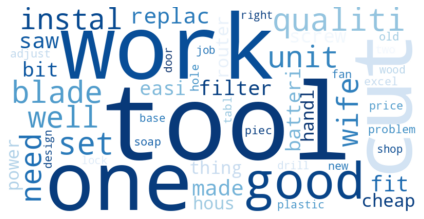

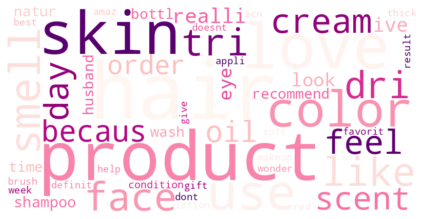

In [60]:
import json
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import os

root = os.getcwd()

# -----------------------------
# Caricamento dati
# -----------------------------
with open(root + "/dict.json", "r") as f:
    user_word_freq = json.load(f)

tokens_df = pd.read_csv(root + "/tokens.csv")

# normalizzazione nomi/autori
tokens_df["firstname"] = tokens_df["firstname"].astype(str).str.lower().str.strip()
tokens_df["gender"] = tokens_df["gender"].astype(str).str.lower().str.strip()

# mapping autore -> gender
user_gender = dict(zip(tokens_df["firstname"], tokens_df["gender"]))

# -----------------------------
# Aggregazione frequenze parole per genere
# -----------------------------
male_counter = Counter()
female_counter = Counter()

for user, word_freqs in user_word_freq.items():
    g = user_gender.get(str(user).lower().strip(), None)
    if g == "male":
        male_counter.update(word_freqs)
    elif g == "female":
        female_counter.update(word_freqs)

male_total = sum(male_counter.values())
female_total = sum(female_counter.values())

all_words = set(male_counter.keys()) | set(female_counter.keys())

# frequenze normalizzate
male_prob = {}
female_prob = {}
for w in all_words:
    male_prob[w] = male_counter.get(w, 0) / male_total if male_total > 0 else 0.0
    female_prob[w] = female_counter.get(w, 0) / female_total if female_total > 0 else 0.0

# -----------------------------
# Bias score
# positivo -> relativamente più maschile
# negativo -> relativamente più femminile
# -----------------------------
filtered_bias = {w: male_prob[w] - female_prob[w] for w in all_words}

# -----------------------------
# Preparazione frequenze per WordCloud
# WordCloud accetta dict {word: frequency}, con valori positivi
# -----------------------------
top_k = 50 # puoi aumentare per word cloud più ricche

male_wc_freq = {
    w: score
    for w, score in filtered_bias.items()
    if score > 0
}

female_wc_freq = {
    w: abs(score)
    for w, score in filtered_bias.items()
    if score < 0
}

# Opzionale: taglia alle top_k parole per ciascun genere
male_wc_freq = dict(
    sorted(male_wc_freq.items(), key=lambda x: x[1], reverse=True)[:top_k]
)
female_wc_freq = dict(
    sorted(female_wc_freq.items(), key=lambda x: x[1], reverse=True)[:top_k]
)

# -----------------------------
# Generazione Word Cloud
# -----------------------------
wc_male = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Blues",
    max_words=top_k,
).generate_from_frequencies(male_wc_freq)

wc_female = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="RdPu",
    max_words=top_k,
).generate_from_frequencies(female_wc_freq)

# -----------------------------
# Plot e salvataggio separato
# -----------------------------
fig_m, ax_m = plt.subplots(figsize=(6,4))
ax_m.imshow(wc_male, interpolation="bilinear")
ax_m.axis("off")
#ax_m.set_title("Words used relatively more by male reviewers", fontsize=14)
plt.tight_layout()
plt.savefig(path_plot + "/wordcloud_male.png", dpi=300, bbox_inches="tight")
#plt.show()

fig_f, ax_f = plt.subplots(figsize=(6,4))
ax_f.imshow(wc_female, interpolation="bilinear")
ax_f.axis("off")
#ax_f.set_title("Words used relatively more by female reviewers", fontsize=14)
plt.tight_layout()
plt.savefig(path_plot + "/wordcloud_female.png", dpi=300, bbox_inches="tight")
#plt.show()